<a href="https://colab.research.google.com/github/HernyBidcom/dashboard-progreso/blob/main/SLA_Logistica_OCA%20EPAK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exploración y automatización de reporte - SLA OCA EPAK frente a Bidcom *SLA*


¡Exportación Exitosa! Excel para bases pesadas y CSV para resúmenes.


### 📊 0A. VALIDACIÓN INICIAL: AUDITORÍA DE CALIDAD DE DATOS

,Auditoría de Calidad y Cruce de Datos,Cantidad,% Relativo
0,1. Total de envíos reportados por API OCA,37284,100.0%
1,2. API OCA: Falla de Endpoint (ERROR HTTP 500),0,0.0%
2,3. API OCA: Con Retiro pero SIN Entrega (Estan...,44,0.1%
3,4. API OCA: Sin Retiro ni Entrega (Registros c...,3,0.0%
4,5. API OCA: Fechas Inconsistentes (Entrega ant...,0,0.0%
5,6. Cruce: Ventas BIDCOM sin tracking en OCA (P...,12262,27.9%
6,7. Tarifario: CPs de Ventas sin match en el Ca...,0,0.0%


### 📊 0B. MATRIZ INTERNA: PACKING VS DESPACHO

SLA_General_Norm,Sla Incumplido,Sla Ok,TOTAL GENERAL
Rendimiento_Packing,,,
1. Packing Rápido (OK),17512 (39.8%),22510 (51.2%),40022 (91.0%)
2. Packing Lento (Atrasado),745 (1.7%),102 (0.2%),847 (1.9%)
3. Sin Datos (Historial de Armado Incompleto),2273 (5.2%),821 (1.9%),3094 (7.0%)
TOTAL GENERAL,20530 (46.7%),23433 (53.3%),43963 (100.0%)


### 📊 1. INCUMPLIMIENTO OCA por PROVINCIA

,Provincia,OCA Incumplido,% OCA Incumple,OCA Cumplido,% OCA Cumple,Suma Total Envíos,Promedio Días Atraso (Excedencia)
0,BUENOS AIRES,6273,66.11%,3216,33.89%,9489,1.6
1,SANTA FE,2444,62.19%,1486,37.81%,3930,1.6
2,CORDOBA,2029,56.44%,1566,43.56%,3595,1.4
3,CAPITAL FEDERAL,1608,74.24%,558,25.76%,2166,1.6
4,MENDOZA,1197,59.4%,818,40.6%,2015,1.6
5,TUCUMAN,794,77.31%,233,22.69%,1027,2.1
6,ENTRE RIOS,538,54.4%,451,45.6%,989,1.5
7,CHUBUT,56,6.5%,806,93.5%,862,0.2
8,NEUQUEN,675,79.32%,176,20.68%,851,2.9
9,SALTA,56,7.7%,671,92.3%,727,0.2


### 📊 2. TRAMOS DE ATRASOS

,Tramo_Penalizacion,Cantidad de Envíos (Global),% de Envíos
0,A tiempo (Sin Atraso),14432,45.5%
1,Atraso Leve (1-2 días),10927,34.5%
2,Atraso Moderado (3-5 días),5223,16.5%
3,Atraso Crítico (>5 días),1114,3.5%
4,TOTAL GENERAL,31696,100.0%


### 📈 1. Empresa vs Logística: Cumplimiento de SLA por Provincia

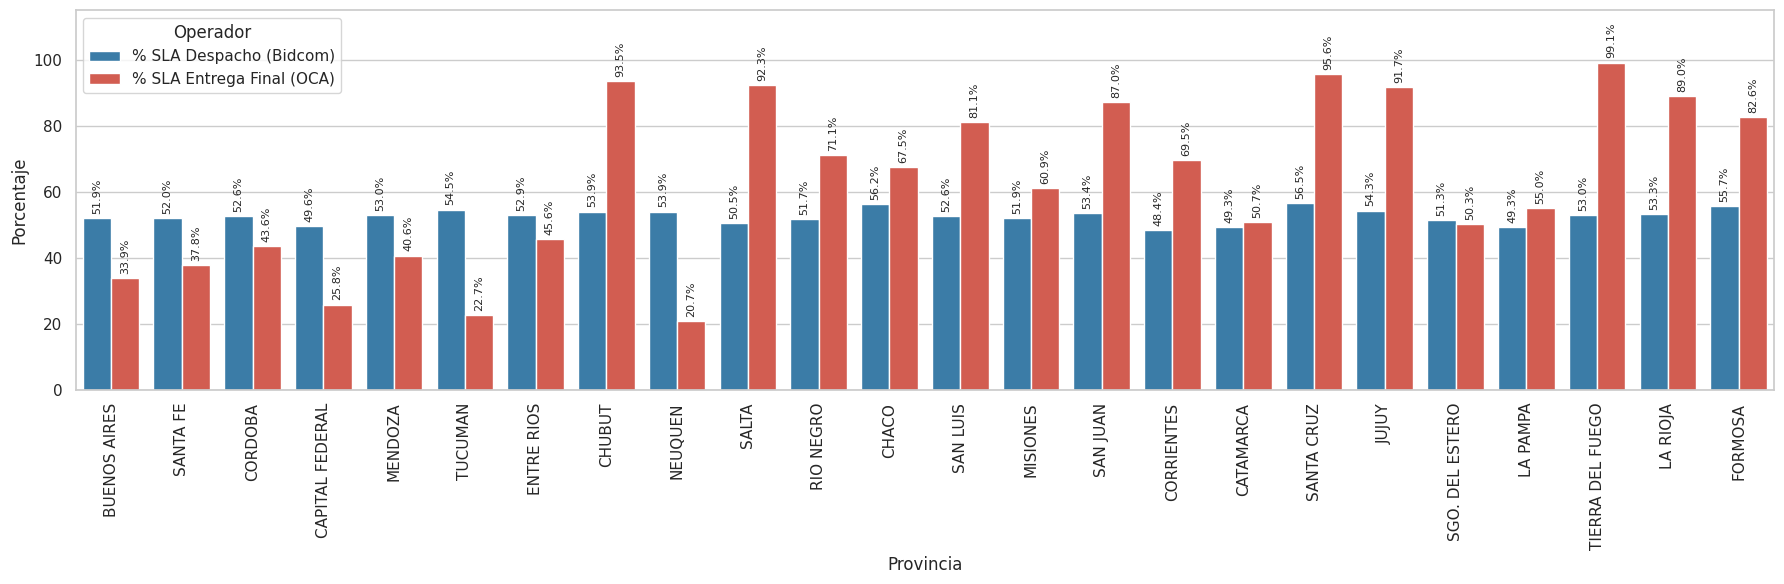

### 📈 2. Impacto de Atrasos: Volumen Total vs Tasa de Incumplimiento OCA

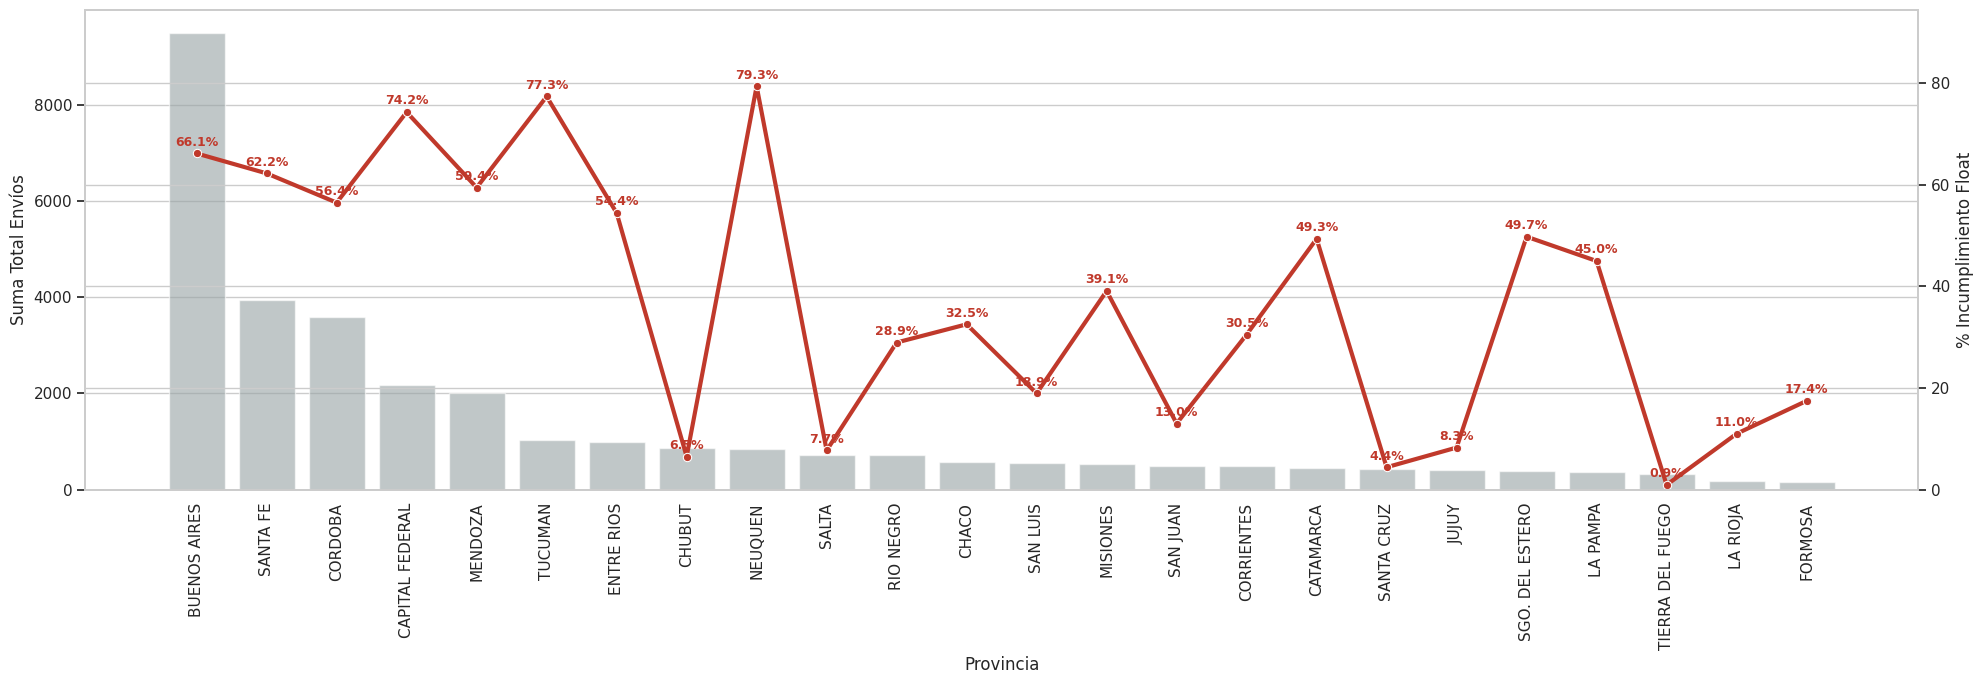

### 📈 3. Distribución de Atrasos Logísticos OCA

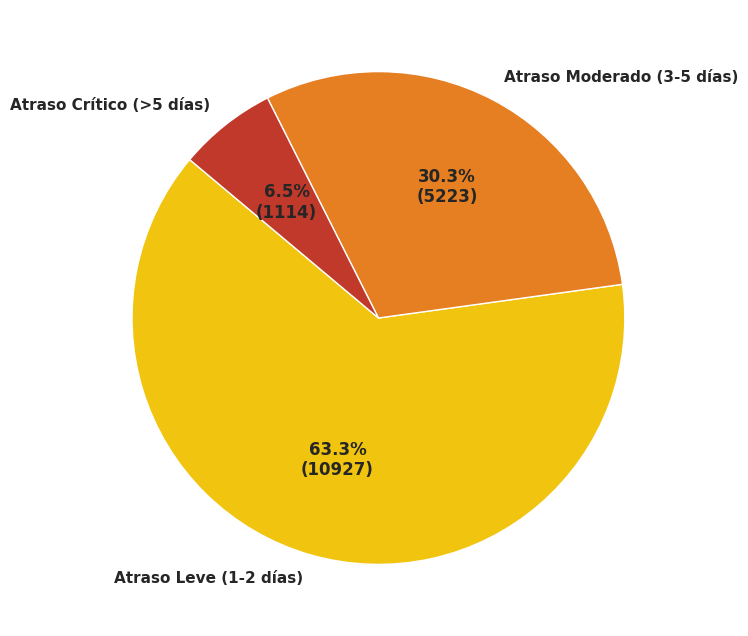

### 📈 4. Radiografía del Desvío de Imposición (Tiempo Retenido por OCA)

/tmp/ipykernel_1486/2961912554.py:438: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_desv = sns.barplot(x='Cantidad', y='Tramo', data=desvio_counts, palette='magma')


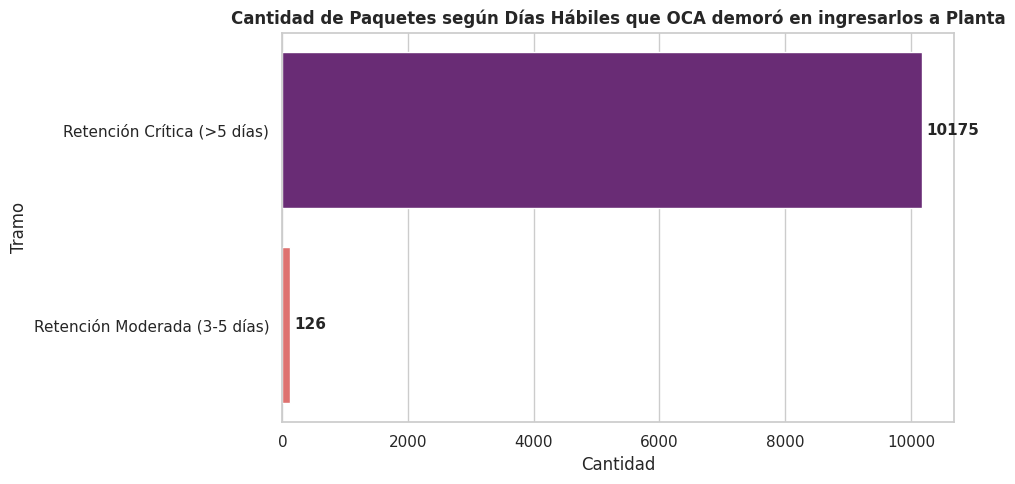

### 📈 5. Desempeño Operativo por Regla Comercial (SLA Permitido vs Real)

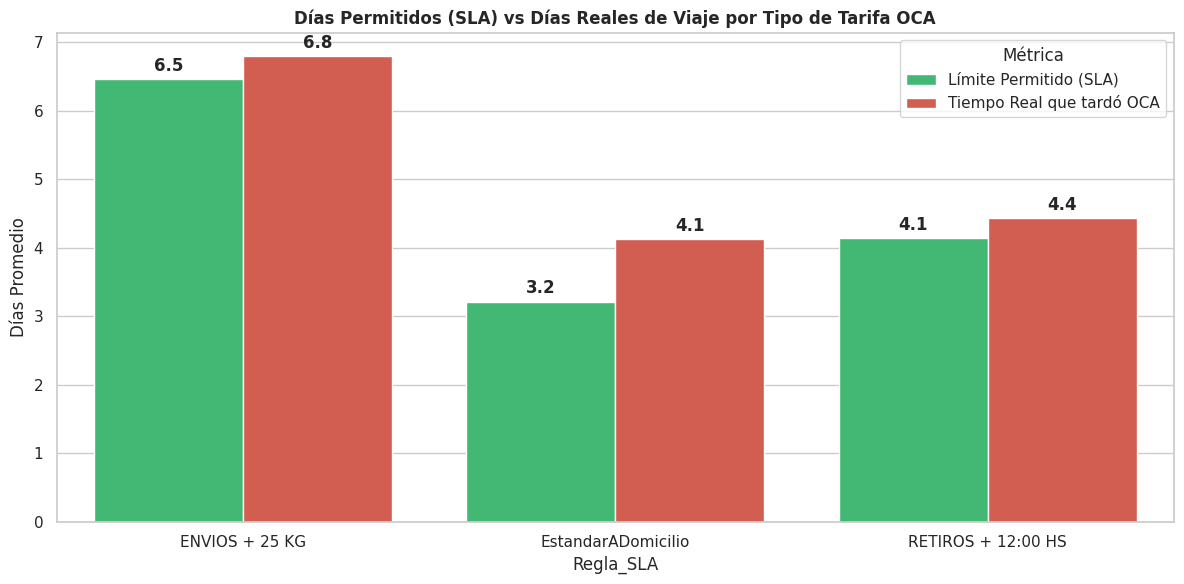

In [19]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# ==========================================
# 0. CONFIGURACIÓN DE ARCHIVOS
# ==========================================
tiempos_file = 'Tiempos de entrega OCA EPAK - Abril 26.xlsx'
ventas_file = 'Ventas OCA PEAK - Abril MC 26.csv'
bidcom_file = 'BIDCOM Canalizador_base_1000_CAPITALFEDERAL.CSV'

# ==========================================
# 1. CARGA DE DATOS Y NORMALIZACIÓN INICIAL
# ==========================================
tiempos_df = pd.read_excel(tiempos_file, dtype=str)
ventas_df = pd.read_csv(ventas_file, on_bad_lines="skip")
bidcom_df = pd.read_csv(bidcom_file, sep=";", encoding="latin1", on_bad_lines="skip")

tiempos_df.columns = tiempos_df.columns.str.strip()
ventas_df.columns = ventas_df.columns.str.strip()
bidcom_df.columns = bidcom_df.columns.str.strip()

if "estado_sla_48hs" in ventas_df.columns:
    ventas_df = ventas_df.rename(columns={"estado_sla_48hs": "estado_sla_dinamico"})

ventas_df['id_cruce'] = ventas_df['idComprobante'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
tiempos_df['id_cruce'] = tiempos_df['Remito'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

# ==========================================
# 2. AUDITORÍA INICIAL Y PAQUETES FANTASMA
# ==========================================
# 🔧 ADVERTENCIAS CORREGIDAS: Parseo limpio sin forzar dayfirst
tiempos_df['tmp_retiro'] = pd.to_datetime(tiempos_df.get('FechaRetiro_Track'), errors='coerce')
tiempos_df['tmp_entrega'] = pd.to_datetime(tiempos_df.get('FechaEntrega_Track'), errors='coerce')

total_api_oca = len(tiempos_df)
en_transito_estancados = (tiempos_df['tmp_retiro'].notna() & tiempos_df['tmp_entrega'].isna()).sum()
totalmente_vacios = (tiempos_df['tmp_retiro'].isna() & tiempos_df['tmp_entrega'].isna()).sum()
fechas_inconsistentes = (tiempos_df['tmp_entrega'] < tiempos_df['tmp_retiro']).sum()
errores_http_500 = (tiempos_df.get('UltimoEstado_Track', pd.Series(dtype=str)).astype(str).str.strip().str.upper() == 'ERROR HTTP 500').sum()

comprobantes_ventas = set(ventas_df['id_cruce'].dropna())
comprobantes_oca = set(tiempos_df['id_cruce'].dropna())
ids_fantasma = comprobantes_ventas - comprobantes_oca
ventas_sin_tracking_oca = len(ids_fantasma)
total_ventas_unicas = len(comprobantes_ventas) if len(comprobantes_ventas) > 0 else 1

df_fantasma = ventas_df[ventas_df['id_cruce'].isin(ids_fantasma)].copy()
columnas_interes = ['idComprobante', 'FechaRetiro_Track', 'estado_sla_dinamico', 'UltimoEstado_Track']
df_fantasma_resumen = df_fantasma[[col for col in columnas_interes if col in df_fantasma.columns]]
df_fantasma_resumen.to_csv("/content/00_B_Listado_Paquetes_Fantasma_Para_Auditar.csv", index=False, encoding="utf-8-sig")

tiempos_df = tiempos_df.drop(columns=['tmp_retiro', 'tmp_entrega'])
if 'FechaEntrega_Track' in tiempos_df.columns:
    tiempos_df = tiempos_df.dropna(subset=['FechaEntrega_Track'])

# ==========================================
# 3. MATRIZ INTERNA: PACKING VS DESPACHO
# ==========================================
ventas_df['sla_packing_horas'] = pd.to_numeric(ventas_df.get('sla_packing_horas', np.nan), errors='coerce')
META_PACKING_HS = 24

condiciones_packing = [
    ventas_df['sla_packing_horas'].isna(),
    ventas_df['sla_packing_horas'] <= META_PACKING_HS,
    ventas_df['sla_packing_horas'] > META_PACKING_HS
]
valores_packing = ['3. Sin Datos (Historial de Armado Incompleto)', '1. Packing Rápido (OK)', '2. Packing Lento (Atrasado)']
ventas_df['Rendimiento_Packing'] = np.select(condiciones_packing, valores_packing, default='Desconocido')
ventas_df['SLA_General_Norm'] = ventas_df.get('estado_sla_dinamico', 'Sin Datos').astype(str).str.strip().str.title()

matriz_interna = pd.crosstab(
    ventas_df['Rendimiento_Packing'],
    ventas_df['SLA_General_Norm'],
    margins=True,
    margins_name="TOTAL GENERAL"
)

if matriz_interna.empty:
    matriz_interna = pd.DataFrame(0, index=["TOTAL GENERAL"], columns=["TOTAL GENERAL"])

total_envios_matriz = matriz_interna.iloc[-1, -1]
total_envios_matriz = total_envios_matriz if total_envios_matriz > 0 else 1
matriz_porcentual = (matriz_interna / total_envios_matriz * 100).round(1).astype(str) + "%"

matriz_final = pd.DataFrame(
    matriz_interna.to_numpy().astype(str) + " (" + matriz_porcentual.to_numpy() + ")",
    index=matriz_interna.index,
    columns=matriz_interna.columns
)
matriz_final.to_csv("/content/00_C_Matriz_Cuellos_Botella_Internos.csv", encoding="utf-8-sig")

# ==========================================
# 4. UNIÓN Y LIMPIEZA MAESTRA
# ==========================================
df_joined = ventas_df.merge(tiempos_df, on="id_cruce", how="inner", suffixes=("_ventas", "_tiempos"))

# 🔧 ADVERTENCIAS CORREGIDAS
df_joined["Fecha_Retiro_dt"] = pd.to_datetime(df_joined["FechaRetiro_Track"], errors="coerce")
df_joined["Fecha_Entrega_dt"] = pd.to_datetime(df_joined["FechaEntrega_Track"], errors="coerce")
df_joined["Fecha_Sucursal_Destino_dt"] = pd.to_datetime(df_joined.get("FechaSucursal_Track"), errors="coerce")
df_joined["Fecha_Imposicion_dt"] = pd.to_datetime(df_joined.get("FechaImposicion"), errors="coerce")

df_joined["Ultimo_Estado"] = df_joined["UltimoEstado_Track"]
df_joined["Estado_Limpio"] = df_joined["UltimoEstado_Track"].astype(str).str.split("-").str[0].str.strip()
df_joined["Tipo_Despacho_Limpio"] = df_joined.get("nombreDespachoTipo", pd.Series(["A DOMICILIO"] * len(df_joined))).astype(str).str.strip().str.upper()

df_joined['codigoSeguimientoDespacho_ventas'] = df_joined['NumeroEnvio'].fillna('').astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
df_joined['idComprobante_ventas'] = df_joined['Remito'].fillna('').astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

df_joined = df_joined.dropna(subset=["Fecha_Retiro_dt"])

# ==========================================
# 5. CRUCE SLA POR CÓDIGO POSTAL Y PROVINCIA
# ==========================================
cp_ventas_col = 'cpLocalidad' if 'cpLocalidad' in df_joined.columns else 'cpLocalidad_ventas'
df_joined['cpLocalidad_clean'] = df_joined[cp_ventas_col].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

posibles_cps = ['CP', 'C.P.', 'CODIGO POSTAL', 'CÓDIGO POSTAL', 'CPLOCALIDAD']
cp_col_bidcom = next((col for col in bidcom_df.columns if str(col).strip().upper() in posibles_cps), None)

if cp_col_bidcom is None:
    cp_col_bidcom = next((col for col in bidcom_df.columns if 'CP' in str(col).upper() or 'POSTAL' in str(col).upper()), None)

if cp_col_bidcom is not None:
    bidcom_df['cp_clean'] = bidcom_df[cp_col_bidcom].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

    mapa_columnas_reales = {}
    for col_real in bidcom_df.columns:
        col_clean = str(col_real).strip().upper().replace(" ", "")
        if "DOMICILIO" in col_clean and "+" not in col_clean:
            mapa_columnas_reales['EstandarADomicilio'] = col_real
        elif "SUCURSAL" in col_clean:
            mapa_columnas_reales['EstandarASucursal'] = col_real
        elif "12" in col_clean or "RETIROS+" in col_clean:
            mapa_columnas_reales['RETIROS + 12:00 HS'] = col_real
        elif "25" in col_clean or "KG" in col_clean:
            mapa_columnas_reales['ENVIOS + 25 KG'] = col_real

    for nombre_estandar, nombre_original in mapa_columnas_reales.items():
        bidcom_df[nombre_original] = pd.to_numeric(bidcom_df[nombre_original], errors='coerce')

    bidcom_unique = bidcom_df.drop_duplicates(subset=['cp_clean'])
    columnas_a_traer = ['cp_clean', 'Provincia', 'Localidad'] + list(mapa_columnas_reales.values())
    df_final = df_joined.merge(bidcom_unique[columnas_a_traer], left_on='cpLocalidad_clean', right_on='cp_clean', how='left')

    for nombre_estandar, nombre_original in mapa_columnas_reales.items():
        if nombre_original in df_final.columns and nombre_original != nombre_estandar:
            df_final = df_final.rename(columns={nombre_original: nombre_estandar})
else:
    df_final = df_joined.copy()
    df_final['Provincia'] = "Sin Datos"

cp_vacios_origen = (df_joined["cpLocalidad_clean"] == "nan").sum()
provincias_sin_match = df_final.get("Provincia", pd.Series(["Sin Datos"])).isna().sum() + (df_final.get("Provincia", pd.Series(["Sin Datos"])) == "Sin Datos").sum()

resumen_validacion_inicial = pd.DataFrame({
    "Auditoría de Calidad y Cruce de Datos": [
        "1. Total de envíos reportados por API OCA",
        "2. API OCA: Falla de Endpoint (ERROR HTTP 500)",
        "3. API OCA: Con Retiro pero SIN Entrega (Estancados / En tránsito)",
        "4. API OCA: Sin Retiro ni Entrega (Registros completamente nulos)",
        "5. API OCA: Fechas Inconsistentes (Entrega antes que Retiro)",
        "6. Cruce: Ventas BIDCOM sin tracking en OCA (Paquetes Fantasma)",
        "7. Tarifario: CPs de Ventas sin match en el Canalizador (Sin Datos)"
    ],
    "Cantidad": [total_api_oca, errores_http_500, en_transito_estancados, totalmente_vacios, fechas_inconsistentes, ventas_sin_tracking_oca, provincias_sin_match],
    "% Relativo": [
        "100.0%", f"{(errores_http_500 / total_api_oca * 100):.1f}%" if total_api_oca>0 else "0%",
        f"{(en_transito_estancados / total_api_oca * 100):.1f}%" if total_api_oca>0 else "0%",
        f"{(totalmente_vacios / total_api_oca * 100):.1f}%" if total_api_oca>0 else "0%",
        f"{(fechas_inconsistentes / total_api_oca * 100):.1f}%" if total_api_oca>0 else "0%",
        f"{(ventas_sin_tracking_oca / total_ventas_unicas * 100):.1f}%",
        f"{(provincias_sin_match / len(df_joined) * 100):.1f}%" if len(df_joined)>0 else "0%"
    ]
})
resumen_validacion_inicial.to_csv("/content/00_A_Auditoria_Calidad_Datos_Inicial.csv", index=False, encoding="utf-8-sig")

# ==========================================
# 6. CÁLCULO DE EXCEDENCIA OCA Y REGLAS SLA
# ==========================================
es_sucursal = df_final['Tipo_Despacho_Limpio'].astype(str).str.contains('SUCURSAL|RETIRAR', case=False, na=False, regex=True)
es_domicilio = df_final['Tipo_Despacho_Limpio'].astype(str).str.contains('DOMICILIO', case=False, na=False, regex=True)
retiro_despues_de_12 = df_final['Fecha_Retiro_dt'].dt.hour >= 12
es_pesado = pd.to_numeric(df_final.get('peso_total_kg', 0), errors='coerce').fillna(0) > 25

condiciones_regla = [es_pesado, es_sucursal, es_domicilio & retiro_despues_de_12, es_domicilio & ~retiro_despues_de_12]
valores_regla = ['ENVIOS + 25 KG', 'EstandarASucursal', 'RETIROS + 12:00 HS', 'EstandarADomicilio']
df_final['Regla_SLA'] = np.select(condiciones_regla, valores_regla, default='Sin Datos')
df_final['SLA_Aplicado'] = 0.0

for regla in valores_regla:
    if regla in df_final.columns:
        mask = df_final['Regla_SLA'] == regla
        df_final.loc[mask, 'SLA_Aplicado'] = pd.to_numeric(df_final.loc[mask, regla], errors='coerce').fillna(0)

df_final['Fecha_Fin_Cronometro_OCA'] = df_final['Fecha_Entrega_dt']
mask_sucursal_valida = es_sucursal & df_final['Fecha_Sucursal_Destino_dt'].notna()
df_final.loc[mask_sucursal_valida, 'Fecha_Fin_Cronometro_OCA'] = df_final.loc[mask_sucursal_valida, 'Fecha_Sucursal_Destino_dt']

df_final['Tiempo_Real_Dias_Habiles'] = np.nan

# 🔧 ERROR FATAL CORREGIDO: Filtro de seguridad para ignorar paquetes sin fecha de entrega final
mask_tiempos = df_final['Fecha_Retiro_dt'].notna() & df_final['Fecha_Fin_Cronometro_OCA'].notna()
if mask_tiempos.sum() > 0:
    start_dates = df_final.loc[mask_tiempos, 'Fecha_Retiro_dt'].values.astype('datetime64[D]')
    end_dates = df_final.loc[mask_tiempos, 'Fecha_Fin_Cronometro_OCA'].values.astype('datetime64[D]')
    df_final.loc[mask_tiempos, 'Tiempo_Real_Dias_Habiles'] = np.busday_count(start_dates, end_dates)

df_final['Cumple_SLA_Habiles'] = df_final['Tiempo_Real_Dias_Habiles'] <= df_final['SLA_Aplicado']
df_final['Dias_Excedencia'] = np.maximum(0, df_final['Tiempo_Real_Dias_Habiles'] - df_final['SLA_Aplicado'])

# Filtro de seguridad para la imposición
df_final['Dias_Desvio_Retiro_a_Imposicion'] = np.nan
mask_imp = df_final['Fecha_Retiro_dt'].notna() & df_final['Fecha_Imposicion_dt'].notna()
if mask_imp.sum() > 0:
    s_imp = df_final.loc[mask_imp, 'Fecha_Retiro_dt'].values.astype('datetime64[D]')
    e_imp = df_final.loc[mask_imp, 'Fecha_Imposicion_dt'].values.astype('datetime64[D]')
    df_final.loc[mask_imp, 'Dias_Desvio_Retiro_a_Imposicion'] = np.busday_count(s_imp, e_imp)

condiciones_desvio = [
    df_final['Dias_Desvio_Retiro_a_Imposicion'].isna(),
    df_final['Dias_Desvio_Retiro_a_Imposicion'] <= 0,
    (df_final['Dias_Desvio_Retiro_a_Imposicion'] >= 1) & (df_final['Dias_Desvio_Retiro_a_Imposicion'] <= 2),
    (df_final['Dias_Desvio_Retiro_a_Imposicion'] >= 3) & (df_final['Dias_Desvio_Retiro_a_Imposicion'] <= 5),
    df_final['Dias_Desvio_Retiro_a_Imposicion'] > 5
]
valores_desvio = [
    'Sin Datos (No Impuesto)',
    'Ingreso Inmediato (0 días)',
    'Demora Aceptable (1-2 días)',
    'Retención Moderada (3-5 días)',
    'Retención Crítica (>5 días)'
]
df_final['Tramo_Desvio_Imposicion'] = np.select(condiciones_desvio, valores_desvio, default='Sin Datos')

# ==========================================
# 7. ESTABLECER UNIVERSO GLOBAL Y DIAGNÓSTICO
# ==========================================
df_final["estado_sla_dinamico"] = df_final["estado_sla_dinamico"].fillna("Sin Datos")
df_final['Packing_Es_Ok'] = df_final['sla_packing_horas'] <= META_PACKING_HS
df_final["BIDCOM_Es_Ok"] = df_final["estado_sla_dinamico"].astype(str).str.strip().str.lower().eq("sla ok")

condiciones_tramos = [
    df_final["Dias_Excedencia"].isna(),
    df_final["Dias_Excedencia"] <= 0,
    (df_final["Dias_Excedencia"] >= 1) & (df_final["Dias_Excedencia"] <= 2),
    (df_final["Dias_Excedencia"] >= 3) & (df_final["Dias_Excedencia"] <= 5),
    df_final["Dias_Excedencia"] > 5
]
df_final["Tramo_Penalizacion"] = np.select(condiciones_tramos, ["Sin Entrega / Cancelado", "A tiempo (Sin Atraso)", "Atraso Leve (1-2 días)", "Atraso Moderado (3-5 días)", "Atraso Crítico (>5 días)"], default="Sin Datos")

condiciones_comp = [(df_final['BIDCOM_Es_Ok'] == True) & (df_final['Cumple_SLA_Habiles'] == True), (df_final['BIDCOM_Es_Ok'] == True) & (df_final['Cumple_SLA_Habiles'] == False), (df_final['BIDCOM_Es_Ok'] == False) & (df_final['Cumple_SLA_Habiles'] == True), (df_final['BIDCOM_Es_Ok'] == False) & (df_final['Cumple_SLA_Habiles'] == False)]
df_final['Comparacion_OCA_BIDCOM'] = np.select(condiciones_comp, ["1. Éxito Total (Ambos Cumplen)", "2. Falla OCA (Responsabilidad Logística)", "3. Falla BIDCOM (OCA salvó la entrega final)", "4. Falla Compartida (Ambos demorados)"], default="Sin Datos")

df_global = df_final.copy()
total_envios_global = len(df_global)
divisor_envios = total_envios_global if total_envios_global > 0 else 1

# ==========================================
# 8. TRAMOS DE PENALIZACIÓN Y PERCENTILES
# ==========================================
resumen_descuentos = df_global.groupby("Tramo_Penalizacion").size().reset_index(name="Cantidad de Envíos (Global)")
resumen_descuentos["% de Envíos"] = (resumen_descuentos["Cantidad de Envíos (Global)"] / divisor_envios * 100).round(1).astype(str) + "%"
orden_tramos = {"Sin Entrega / Cancelado": 0, "A tiempo (Sin Atraso)": 1, "Atraso Leve (1-2 días)": 2, "Atraso Moderado (3-5 días)": 3, "Atraso Crítico (>5 días)": 4}
resumen_descuentos["Orden"] = resumen_descuentos["Tramo_Penalizacion"].map(orden_tramos)
resumen_descuentos = resumen_descuentos.sort_values("Orden").drop(columns=["Orden"])
fila_total_desc = pd.DataFrame({'Tramo_Penalizacion': ['TOTAL GENERAL'], 'Cantidad de Envíos (Global)': [total_envios_global], '% de Envíos': ['100.0%']})
resumen_descuentos = pd.concat([resumen_descuentos, fila_total_desc], ignore_index=True)

def generar_percentiles(df, columna):
    df_temp = df.copy()
    if len(df_temp) == 0 or columna not in df_temp.columns:
        return pd.DataFrame()
    df_temp[columna] = df_temp[columna].fillna("Sin Datos")
    df_agrupado = (df_temp.groupby(columna)["Dias_Excedencia"].agg(Cantidad_Envios="count", Promedio="mean", Mediana="median", P75=lambda s: s.quantile(0.75), P90=lambda s: s.quantile(0.90), Maximo="max").round(1).reset_index())
    fila_total = pd.DataFrame([{columna: "TOTAL GENERAL", "Cantidad_Envios": len(df_temp), "Promedio": round(df_temp["Dias_Excedencia"].mean(), 1), "Mediana": round(df_temp["Dias_Excedencia"].median(), 1), "P75": round(df_temp["Dias_Excedencia"].quantile(0.75), 1), "P90": round(df_temp["Dias_Excedencia"].quantile(0.90), 1), "Maximo": round(df_temp["Dias_Excedencia"].max(), 1)}])
    df_agrupado = pd.concat([df_agrupado, fila_total], ignore_index=True)
    df_agrupado["Clientes_Peor_Escenario_(10%)"] = (df_agrupado["Cantidad_Envios"] * 0.10).astype(int)
    return pd.concat([df_agrupado[df_agrupado[columna] != "TOTAL GENERAL"].sort_values(["P90", "Cantidad_Envios"], ascending=[False, False]), df_agrupado[df_agrupado[columna] == "TOTAL GENERAL"]], ignore_index=True)

percentiles_provincia = generar_percentiles(df_global, "Provincia")

# ==========================================
# 9. RESÚMENES GENERALES Y CRUCES BLINDADOS
# ==========================================
df_global["Cumple_SLA_Habiles_str"] = df_global["Cumple_SLA_Habiles"].map({True: "TRUE", False: "FALSE"})

def generar_cruce(df, columna):
    if len(df) == 0 or columna not in df.columns: return pd.DataFrame()
    pivot_oca = pd.crosstab(df[columna].fillna("Sin Datos"), df["Cumple_SLA_Habiles_str"], margins=True, margins_name="TOTAL GENERAL")
    for c in ["FALSE", "TRUE", "TOTAL GENERAL"]:
        if c not in pivot_oca.columns: pivot_oca[c] = 0
    pivot_oca["% OCA Incumple"] = (pivot_oca["FALSE"] / pivot_oca["TOTAL GENERAL"].replace(0, np.nan) * 100).fillna(0).round(2).astype(str) + "%"
    pivot_oca["% OCA Cumple"] = (pivot_oca["TRUE"] / pivot_oca["TOTAL GENERAL"].replace(0, np.nan) * 100).fillna(0).round(2).astype(str) + "%"
    pivot_oca = pivot_oca[["FALSE", "% OCA Incumple", "TRUE", "% OCA Cumple", "TOTAL GENERAL"]].rename(columns={"TOTAL GENERAL": "Suma Total Envíos", "FALSE": "OCA Incumplido", "TRUE": "OCA Cumplido"})
    excedencia = df.groupby(columna, dropna=False)["Dias_Excedencia"].mean().round(1).reset_index().rename(columns={"Dias_Excedencia": "Promedio Días Atraso (Excedencia)"})
    resumen = pivot_oca.drop("TOTAL GENERAL", errors="ignore").sort_values("Suma Total Envíos", ascending=False)
    resumen = pd.concat([resumen, pivot_oca.loc[["TOTAL GENERAL"]]]) if "TOTAL GENERAL" in pivot_oca.index else resumen
    resumen.reset_index(names=columna, inplace=True)
    return resumen.merge(excedencia, on=columna, how="left").fillna("-")

resumen_provincia = generar_cruce(df_global, "Provincia")
resumen_deposito = generar_cruce(df_global, "deposito")
resumen_tipo_despacho = generar_cruce(df_global, "Tipo_Despacho_Limpio")

# ==========================================
# 9.B GENERACIÓN DE LA TABLA ORDENADA GERENCIAL
# ==========================================
df_gerencial = df_global.copy()

if 'cpLocalidad_clean' in df_gerencial.columns:
    df_gerencial = df_gerencial.rename(columns={'cpLocalidad_clean': 'CodigoPostal'})

df_gerencial['estado_sla_dinamico'] = np.select([df_gerencial['BIDCOM_Es_Ok'] == True, df_gerencial['BIDCOM_Es_Ok'] == False], ['Bidcom cumplió', 'Bidcom incumplió'], default='Sin Datos')

columnas_gerenciales = [
    'codigoSeguimientoDespacho_ventas',
    'idComprobante_ventas',
    'ProductoID',
    'cantidad_productos',
    'estado_sla_dinamico',
    'fechaEnvioDespachoFinal',
    'Fecha_Retiro_dt',
    'Fecha_Imposicion_dt',
    'Fecha_Entrega_dt',
    'Fecha_Sucursal_Destino_dt',
    'Ultimo_Estado',
    'peso_total_kg',
    'Tipo_Despacho_Limpio',
    'CodigoPostal',
    'Provincia',
    'EstandarADomicilio',
    'EstandarASucursal',
    'RETIROS + 12:00 HS',
    'ENVIOS + 25 KG',
    'SLA_Aplicado',
    'Regla_SLA',
    'Tiempo_Real_Dias_Habiles',
    'Dias_Desvio_Retiro_a_Imposicion',
    'Tramo_Desvio_Imposicion',
    'Dias_Excedencia',
    'Tramo_Penalizacion',
    'Comparacion_OCA_BIDCOM'
]

columnas_existentes = [col for col in columnas_gerenciales if col in df_gerencial.columns]
df_gerencial_ordenada = df_gerencial[columnas_existentes].copy()

# ==========================================
# 10. EXPORTACIÓN DE ARCHIVOS
# ==========================================
columnas_fechas = ["Fecha_Retiro_dt", "Fecha_Entrega_dt", "Fecha_Sucursal_Destino_dt", "Fecha_Imposicion_dt"]
for col in columnas_fechas:
    formato_fecha = "%Y-%m-%d" if col == "Fecha_Imposicion_dt" else "%Y-%m-%d %H:%M:%S"
    if col in df_global.columns:
        df_global[col] = pd.to_datetime(df_global[col], errors='coerce').dt.strftime(formato_fecha)
    if col in df_gerencial_ordenada.columns:
        df_gerencial_ordenada[col] = pd.to_datetime(df_gerencial_ordenada[col], errors='coerce').dt.strftime(formato_fecha)

df_global.to_excel("/content/01_Base_Maestra_SLA_Completa_BRUTO.xlsx", index=False)
df_gerencial_ordenada.to_excel("/content/01_B_Base_Gerencial_SLA_Ordenada.xlsx", index=False)

exports_csv = {
    "02_Analisis_Tramos_Atraso_Global.csv": resumen_descuentos,
    "04_Analisis_Percentiles_Excedencia_P90.csv": percentiles_provincia,
    "05_Comparativa_Provincias_Global.csv": resumen_provincia,
    "06_Comparativa_Depositos_Global.csv": resumen_deposito,
    "07_Comparativa_TipoDespacho_Global.csv": resumen_tipo_despacho,
}
for filename, dataframe in exports_csv.items():
    dataframe.to_csv(f"/content/{filename}", index=False, encoding="utf-8-sig")

print("\n¡Exportación Exitosa! Excel para bases pesadas y CSV para resúmenes.")

# ==========================================
# 11 y 12. VISUALIZACIONES Y GRÁFICOS
# ==========================================
def mostrar_tabla_limpia(df, titulo):
    display(Markdown(f"### 📊 {titulo}"))
    if len(df) == 0:
        print("No hay datos para mostrar.")
    else:
        display(df)

mostrar_tabla_limpia(resumen_validacion_inicial, "0A. VALIDACIÓN INICIAL: AUDITORÍA DE CALIDAD DE DATOS")
mostrar_tabla_limpia(matriz_final, "0B. MATRIZ INTERNA: PACKING VS DESPACHO")
mostrar_tabla_limpia(resumen_provincia, "1. INCUMPLIMIENTO OCA por PROVINCIA")
mostrar_tabla_limpia(resumen_descuentos, "2. TRAMOS DE ATRASOS")

if len(df_joined) > 0:
    sns.set_theme(style="whitegrid")

    display(Markdown("### 📈 1. Empresa vs Logística: Cumplimiento de SLA por Provincia"))
    comp_df = df_global.groupby('Provincia').agg(Total=('id_cruce', 'count'), Despacho_OK=('BIDCOM_Es_Ok', 'sum'), OCA_OK=('Cumple_SLA_Habiles', 'sum')).reset_index()
    comp_df['% SLA Despacho (Bidcom)'] = (comp_df['Despacho_OK'] / comp_df['Total']) * 100
    comp_df['% SLA Entrega Final (OCA)'] = (comp_df['OCA_OK'] / comp_df['Total']) * 100
    comp_df = comp_df.sort_values('Total', ascending=False)
    comp_df_melted = comp_df.melt(id_vars='Provincia', value_vars=['% SLA Despacho (Bidcom)', '% SLA Entrega Final (OCA)'], var_name='Operador', value_name='Porcentaje')
    plt.figure(figsize=(18, 6))
    ax = sns.barplot(x='Provincia', y='Porcentaje', hue='Operador', data=comp_df_melted, palette=['#2980B9', '#E74C3C'])
    plt.xticks(rotation=90)
    plt.ylim(0, 115)
    for container in ax.containers: ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8, rotation=90)
    plt.tight_layout()
    plt.show()

    display(Markdown("### 📈 2. Impacto de Atrasos: Volumen Total vs Tasa de Incumplimiento OCA"))
    plot_df2 = resumen_provincia[resumen_provincia['Provincia'] != 'TOTAL GENERAL'].copy()
    plot_df2['% Incumplimiento Float'] = plot_df2['% OCA Incumple'].str.replace('%', '').astype(float)
    plot_df2 = plot_df2.sort_values('Suma Total Envíos', ascending=False).reset_index(drop=True)
    fig, ax3 = plt.subplots(figsize=(20, 7))
    sns.barplot(x='Provincia', y='Suma Total Envíos', data=plot_df2, ax=ax3, color='#95A5A6', alpha=0.6)
    ax3.tick_params(axis='x', rotation=90)
    ax4 = ax3.twinx()
    sns.lineplot(x='Provincia', y='% Incumplimiento Float', data=plot_df2, ax=ax4, color='#C0392B', marker='o', linewidth=3)
    ax4.set_ylim(0, max(plot_df2['% Incumplimiento Float']) + 15)
    for i, row in plot_df2.iterrows(): ax4.text(i, row['% Incumplimiento Float'] + 1.5, f"{row['% Incumplimiento Float']:.1f}%", color='#C0392B', ha='center', fontweight='bold', fontsize=9)
    plt.tight_layout()
    plt.show()

    display(Markdown("### 📈 3. Distribución de Atrasos Logísticos OCA"))
    plot_df3 = resumen_descuentos[(resumen_descuentos['Tramo_Penalizacion'] != 'TOTAL GENERAL') & (resumen_descuentos['Tramo_Penalizacion'] != 'A tiempo (Sin Atraso)')]
    if len(plot_df3) > 0 and plot_df3['Cantidad de Envíos (Global)'].sum() > 0:
        plt.figure(figsize=(8, 8))
        plt.pie(plot_df3['Cantidad de Envíos (Global)'], labels=plot_df3['Tramo_Penalizacion'], autopct=lambda pct: f"{pct:.1f}%\n({int(np.round(pct/100.*plot_df3['Cantidad de Envíos (Global)'].sum()))})", startangle=140, colors=['#F1C40F', '#E67E22', '#C0392B'], textprops={'fontweight': 'bold'})
        plt.show()

    display(Markdown("### 📈 4. Radiografía del Desvío de Imposición (Tiempo Retenido por OCA)"))
    desvio_counts = df_global['Tramo_Desvio_Imposicion'].value_counts().reset_index()
    desvio_counts.columns = ['Tramo', 'Cantidad']
    desvio_counts = desvio_counts[~desvio_counts['Tramo'].isin(['Sin Datos (No Impuesto)', 'Ingreso Inmediato (0 días)', 'Sin Datos'])]
    if len(desvio_counts) > 0:
        plt.figure(figsize=(10, 5))
        ax_desv = sns.barplot(x='Cantidad', y='Tramo', data=desvio_counts, palette='magma')
        plt.title('Cantidad de Paquetes según Días Hábiles que OCA demoró en ingresarlos a Planta', fontweight='bold')
        for container in ax_desv.containers: ax_desv.bar_label(container, padding=3, fontweight='bold', fontsize=11)
        plt.tight_layout()
        plt.show()

    display(Markdown("### 📈 5. Desempeño Operativo por Regla Comercial (SLA Permitido vs Real)"))
    reglas_df = df_global[df_global['Regla_SLA'] != 'Sin Datos'].groupby('Regla_SLA').agg(
        Promedio_SLA_Aplicado=('SLA_Aplicado', 'mean'),
        Promedio_Tiempo_Real=('Tiempo_Real_Dias_Habiles', 'mean')
    ).reset_index()
    if len(reglas_df) > 0:
        reglas_melted = reglas_df.melt(id_vars='Regla_SLA', value_vars=['Promedio_SLA_Aplicado', 'Promedio_Tiempo_Real'], var_name='Métrica', value_name='Días Promedio')
        reglas_melted['Métrica'] = reglas_melted['Métrica'].map({'Promedio_SLA_Aplicado': 'Límite Permitido (SLA)', 'Promedio_Tiempo_Real': 'Tiempo Real que tardó OCA'})
        plt.figure(figsize=(12, 6))
        ax_reglas = sns.barplot(x='Regla_SLA', y='Días Promedio', hue='Métrica', data=reglas_melted, palette=['#2ECC71', '#E74C3C'])
        plt.title('Días Permitidos (SLA) vs Días Reales de Viaje por Tipo de Tarifa OCA', fontweight='bold')
        for container in ax_reglas.containers: ax_reglas.bar_label(container, fmt='%.1f', padding=3, fontweight='bold')
        plt.tight_layout()
        plt.show()